In [5]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature







from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'normal'

In [6]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [7]:

def detrend_yearly_limited(s, start_year=1991, end_year=2020):
    # Extract years and values
    years = s.year.values
    values = s.values

    # Filter the data for the specified range (1990-2020)
    mask = (years >= start_year) & (years <= end_year)
    years_subset = years[mask]
    values_subset = values[mask]

    # Fit a linear trend to the subset of data
    slope, intercept, _, _, _ = stats.linregress(years_subset, values_subset)

    # Compute the trend based on the entire time span using the calculated slope and intercept
    trend = slope * years + intercept

    # Detrend the data
    detrended_values = values - trend

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data


In [8]:

from statsmodels.nonparametric.smoothers_lowess import lowess

def detrend_yearly_loess_full(s, frac=0.6):
    """
    Detrend a full time series using LOESS smoothing.
    
    Parameters:
        s (xr.DataArray): Input data with a 'year' coordinate.
        frac (float): Fraction of data used for LOESS smoothing (controls smoothness).
    
    Returns:
        xr.DataArray: Detrended data array.
    """
    # Extract years and values
    years = s.year.values
    values = s.values

    # Apply LOESS smoothing to the full dataset
    loess_fit = lowess(values, years, frac=frac, return_sorted=False)
    
    plt.plot(loess_fit)
    plt.plot(values)
    

    # Detrend the data
    detrended_values = values - loess_fit

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data


# T500

In [9]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', '2023'), lat = slice(25, -15)).sel(plev = 50000)
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])


In [10]:
#convert to potential temperature
t500 = convert_to_potential_temperature(t500, 500)

In [11]:
#ASO season
t500_aso = t500.where(t500.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

clim = t500_aso.sel(year = slice('1991', '2020')).ocean_mean.mean('year')

#ASO anom
t500_aso['ocean_anom'] = t500_aso.ocean_mean - clim

In [12]:
t500_aso['det'] = detrend_yearly_limited(t500_aso.ocean_anom)

Text(0.5, 1.0, 't500_aso')

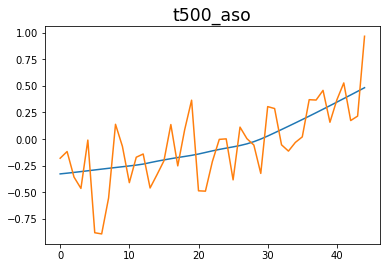

In [13]:
t500_aso['det'] = detrend_yearly_loess_full(t500_aso.ocean_anom)
plt.title('t500_aso')

###  Ocean Mask

In [14]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifc
#ocean_mask = masks.seamask ==1

## w500

In [15]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(25, -15), time= slice('1979', None))

w500 = w500.where(ocean_mask)



#convert to hpa/day
w500 = w500*(24*3600/100)

In [16]:
#creat weights
weights = np.cos(np.deg2rad(w500.lat))

deep_conv = w500<-40
deep_conv_area = deep_conv.weighted(weights).mean(['lat', 'lon'])
clim = deep_conv_area.sel(time = slice('1991', '2020')).groupby('time.month').mean() #clim of deep convection area
deep_conv_area_anom = deep_conv_area.groupby('time.month')-clim

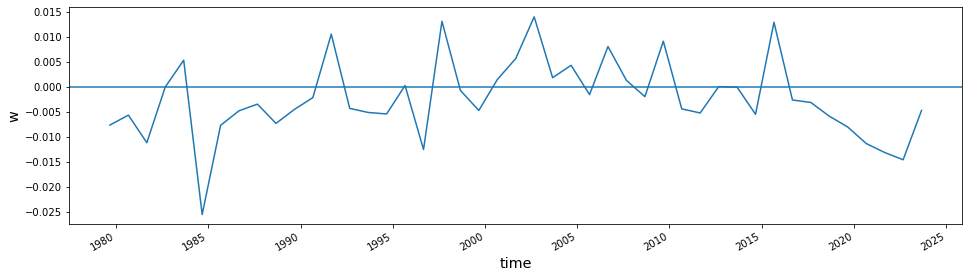

In [17]:
aso = deep_conv_area_anom.rolling(time = 3, center = True).mean()
aso = aso.where(aso.time.dt.month == 9, drop = True)
aso.w.plot(size = 4, aspect = 4)
plt.axhline(0)

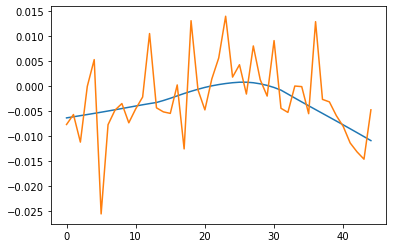

In [18]:
deep_conv_area_anom = deep_conv_area_anom.where(t500.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

deep_conv_area_anom['det'] = detrend_yearly_loess_full(deep_conv_area_anom.w)


## SST

In [19]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))
#ocean_mask = ~sst.isel(time = 1).sst.isnull()
sst = sst.where(ocean_mask)

In [20]:
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [21]:
# compute nino34 for aso 
nino34 = sst_aso.sel(lat = slice(15, -15), lon = slice(190, 240))
nino34 = nino34 - nino34.sel(year = slice('1991', '2020')).mean('year')
nino34 = nino34.weighted(np.cos(np.deg2rad(nino34.lat))).mean(['lat', 'lon'])


## TP

In [22]:
fp = '/data/jmex/NOAA/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice('1979','2023'))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})

#tp aso only 

tp_aso = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [23]:
#interp sst to match gpcp
sst_aso = sst_aso.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')

#second ocean_mask, on the GPCP grid
#make ocean mask
ocean_mask2 = ~sst_aso.isel(year = 1).sst.isnull()


#take t for ocean mask only: 
tp_aso = tp_aso.where(ocean_mask2)

weights = np.cos(np.deg2rad(tp.lat))
tp_aso['ocean_mean'] = tp_aso.tp.weighted(weights).mean(['lat', 'lon'])

## PWS

In [24]:
pws_aso = xr.zeros_like(sst_aso)
pws_aso = pws_aso.rename({'sst': 'pws'})

In [25]:
pws_aso['pws'] = sst_aso.sst * tp_aso.tp/tp_aso.ocean_mean 

pws_aso['pws_mean'] = pws_aso.pws.weighted(weights).mean(['lat', 'lon'])
#subtract mean
pws_aso['pws_mean'] = pws_aso['pws_mean']-pws_aso.pws_mean.mean()

In [26]:
pws_aso['pws_detrended'] = detrend_yearly_limited(pws_aso.pws_mean)

Text(0.5, 1.0, 'pws_aso, gpcp')

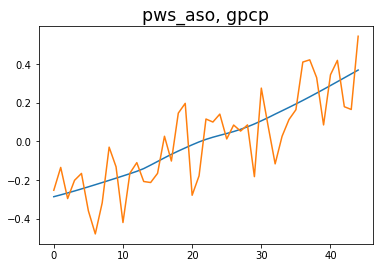

In [27]:
pws_aso['pws_detrended'] = detrend_yearly_loess_full(pws_aso.pws_mean)
plt.title('pws_aso, gpcp')

### t2m


In [28]:
#import t2m
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp).sel(time = slice('1979', '2023'))


In [29]:
t2m_aso = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [30]:
t2m_aso = t2m_aso.weighted(weights).mean(['lat', 'lon'])

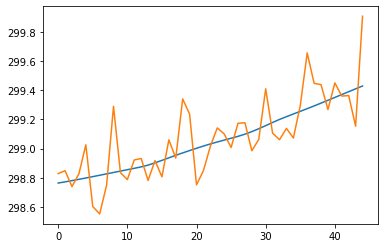

In [31]:
t2m_aso['t2m_detrended'] = detrend_yearly_loess_full(t2m_aso.t2m)

## Regression

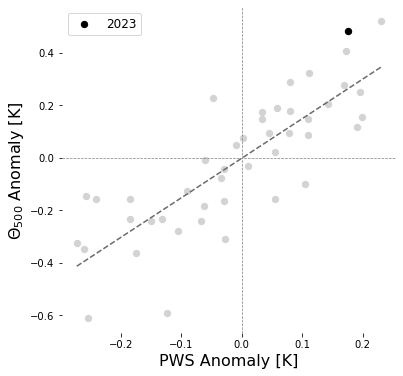

In [32]:
def plot_with_regression(ax, x, y, x_label, highlight_index = []):
    # Reshape for sklearn (requires 2D array for features)
    x_reshaped = x.reshape(-1, 1)

    # Regression
    model = LinearRegression()
    model.fit(x_reshaped, y)
    y_pred = model.predict(x_reshaped)
    r2 = r2_score(y, y_pred)

    # Scatter plot
    scatter = ax.scatter(x, y, s = 40, c = 'lightgrey')#c=nino34.sst.values, cmap = 'RdBu_r', s=40)
    
    #highlight 2023
    scatter = ax.scatter(x[-1:], y[-1:], c ='k',  s=40, label = '2023')

    for i in highlight_index:
        scatter = ax.scatter(x[i+1], y[i+1], label = pws_aso.year[i].values,  s=40)
    
    
    
    
    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='dimgrey', linestyle='--', )#label=f'$R^2 = {r2:.2f}$')
    
    # Dashed lines at zero
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

    # Only display horizontal grid lines and remove the plot frame
    ax.yaxis.grid(False)  # Horizontal grid lines
    ax.xaxis.grid(False)  # No vertical grid lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Labels and title
    ax.set_xlabel(x_label, fontsize = 16)
    ax.set_ylabel(r'$\Theta_{500}$ Anomaly [K]', fontsize = 16)
    
    ax.legend(fontsize = 12)
    
    #compute residuals
    residuals = y-y_pred

    return scatter, residuals


rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'


# Create figure with two subplots
fig, axes = plt.subplots(1, 1, figsize=(6, 6), sharey=True)


# Plot 2
scatter2, residuals = plot_with_regression(axes, pws_aso.pws_detrended.values, t500_aso.det, 
                                         x_label = r'PWS Anomaly [K]') 
#                                          ,highlight_index = [3,8,12,18,36])


#fig.suptitle(r"ASO $T_{500}$ Anomaly, LOESS", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()


In [33]:
weights = np.cos(np.deg2rad(sst.lat))
sst_aso = sst_aso.weighted(weights).mean(['lat', 'lon'])

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


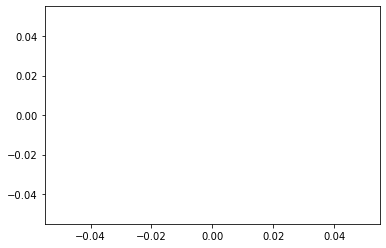

In [34]:
sst_aso['sst_detrended'] = detrend_yearly_loess_full(sst_aso.sst)

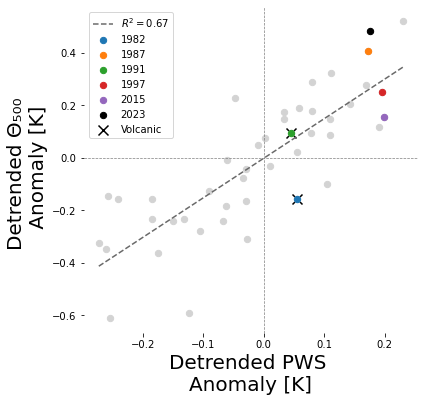

In [35]:
def plot_with_regression(ax, x, y, x_label, highlight_index = [], volc_index = []):
    # Reshape for sklearn (requires 2D array for features)
    x_reshaped = x.reshape(-1, 1)

    # Regression
    model = LinearRegression()
    model.fit(x_reshaped, y)
    y_pred = model.predict(x_reshaped)
    r2 = r2_score(y, y_pred)

    # Scatter plot
    scatter = ax.scatter(x, y, c='lightgrey', cmap = 'RdBu_r', s=40)
    
   
    for i in highlight_index:
        scatter = ax.scatter(x[i], y[i], label = pws_aso.year[i].values,  s=40)
    
    #highlight 2023
    scatter = ax.scatter(x[-1:], y[-1:], c ='k',  s=40, label = '2023')
 
    #highlight volcanic
    scatter = ax.scatter(x[volc_index[0]], y[volc_index[0]], c ='k',  s=100, marker = 'x', zorder = 0, label = 'Volcanic')
    
    for i in volc_index[1:]:
        scatter = ax.scatter(x[i], y[i], c ='k',  s=100, marker = 'x', zorder = 0)
 
    
    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='dimgrey', linestyle='--', label=f'$R^2 = {r2:.2f}$')
    
    # Dashed lines at zero
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

    # Only display horizontal grid lines and remove the plot frame
    ax.yaxis.grid(False)  # Horizontal grid lines
    ax.xaxis.grid(False)  # No vertical grid lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Labels and title
    ax.set_xlabel(x_label, fontsize = 20)
    ax.set_ylabel('Detrended Θ₅₀₀ \n Anomaly [K]', fontsize = 20)
    
    ax.legend()
    
    #compute residuals
    residuals = y-y_pred

    return scatter, residuals


rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'


# Create figure with two subplots
fig, axes = plt.subplots(1, 1, figsize=(6, 6), sharey=True)


# Plot 2
scatter2, residuals = plot_with_regression(axes, pws_aso.pws_detrended.values, t500_aso.det, 
                                         x_label = 'Detrended PWS \nAnomaly [K]'
                                          ,highlight_index = [3,8,12,18,36], 
                                          volc_index = [3, 12])


#fig.suptitle(r"ASO $T_{500}$ Anomaly, LOESS", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()


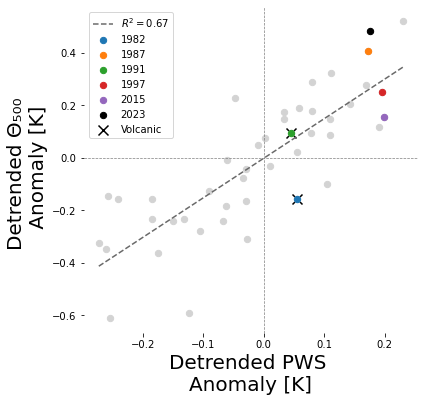

In [36]:
def plot_with_regression(ax, x, y, x_label, highlight_index = [], volc_index = []):
    # Reshape for sklearn (requires 2D array for features)
    x_reshaped = x.reshape(-1, 1)

    # Regression
    model = LinearRegression()
    model.fit(x_reshaped, y)
    y_pred = model.predict(x_reshaped)
    r2 = r2_score(y, y_pred)

    # Scatter plot
    scatter = ax.scatter(x, y, c='lightgrey', cmap = 'RdBu_r', s=40)
    
   
    for i in highlight_index:
        scatter = ax.scatter(x[i], y[i], label = pws_aso.year[i].values,  s=40)
    
    #highlight 2023
    scatter = ax.scatter(x[-1], y[-1], c ='k',  s=40, label = '2023')
 
    #highlight volcanic
    scatter = ax.scatter(x[volc_index[0]], y[volc_index[0]], c ='k',  s=100, marker = 'x', zorder = 0, label = 'Volcanic')
    
    for i in volc_index[1:]:
        scatter = ax.scatter(x[i], y[i], c ='k',  s=100, marker = 'x', zorder = 0)
 
    
    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='dimgrey', linestyle='--', label=f'$R^2 = {r2:.2f}$')
    
    # Dashed lines at zero
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

    # Only display horizontal grid lines and remove the plot frame
    ax.yaxis.grid(False)  # Horizontal grid lines
    ax.xaxis.grid(False)  # No vertical grid lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Labels and title
    ax.set_xlabel(x_label, fontsize = 20)
    ax.set_ylabel('Detrended Θ₅₀₀ \n Anomaly [K]', fontsize = 20)
    
    ax.legend()
    
    #compute residuals
    residuals = y-y_pred

    return scatter, residuals


rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'


# Create figure with two subplots
fig, axes = plt.subplots(1, 1, figsize=(6, 6), sharey=True)


# Plot 2
scatter2, residuals = plot_with_regression(axes, pws_aso.pws_detrended.values, t500_aso.det, 
                                         x_label = 'Detrended PWS \nAnomaly [K]'
                                          ,highlight_index = [3,8,12,18,36], 
                                          volc_index = [3, 12])


#fig.suptitle(r"ASO $T_{500}$ Anomaly, LOESS", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

def plot_with_regression(ax, x, y, x_label, years, highlight_years=[], volc_years=[]):
    x = np.asarray(x)
    y = np.asarray(y)
    years = np.asarray(years)
    
    # Fit regression
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, y_pred)

    # Base scatter
    ax.scatter(x, y, c='lightgrey', s=40, label='_base')

    # Color palette for highlighted years
    color_palette = sns.color_palette("colorblind", len(highlight_years))
    year_color_map = dict(zip(highlight_years, color_palette))

    # Plot highlighted years and their previous years
    for i, yr in enumerate(highlight_years):
        idx = np.where(years == yr)[0][0]
        ax.scatter(x[idx], y[idx], color=year_color_map[yr], s=80, label=str(yr), zorder=3)

        # Mark the previous year
        prev_year = yr - 1
        if prev_year in years:
            prev_idx = np.where(years == prev_year)[0][0]
            ax.scatter(x[prev_idx], y[prev_idx], 
                       facecolor='lightgrey', edgecolor=year_color_map[yr], 
                       linewidth=2, s=60, zorder=2)

    # Highlight 2023
    if 2023 in years:
        idx_2023 = np.where(years == 2023)[0][0]
        idx_2022 = np.where(years == 2022)[0][0]

        # Plot 2023
        ax.scatter(x[idx_2023], y[idx_2023], c='black', s=80, label='2023', zorder=4)

        # Plot 2022
        ax.scatter(x[idx_2022], y[idx_2022], facecolor='lightgrey', edgecolor='black',
                   linewidth=2, s=60, label='2022/Year [-1]', zorder=4)

        # Draw arrow from 2022 to 2023
        ax.annotate(
            '',
            xy=(x[idx_2023], y[idx_2023]),
            xytext=(x[idx_2022], y[idx_2022]),
            arrowprops=dict(
                arrowstyle='->,head_length=2,head_width=1',  # smaller head
                linestyle='solid',#(0, (1, 5)),  
                color='black',
                lw=1.2  # slightly thinner
            ),
            zorder=3
        )


    # Volcanic years (black x)
    for j, volc_year in enumerate(volc_years):
        if volc_year in years:
            idx_volc = np.where(years == volc_year)[0][0]
            ax.scatter(x[idx_volc], y[idx_volc], c='black', s=100, marker='x', linewidths=2.0,
                       label='Volcanic' if j == 0 else None, zorder=1)

    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='dimgrey', linestyle='--', label=f'$R^2 = {r2:.2f}$')

    # Zero lines
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)

    # Aesthetic cleanup
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Labels
    ax.set_xlabel(x_label, fontsize=20)
    ax.set_ylabel('Detrended Θ₅₀₀ \n Anomaly [K]', fontsize=20)
    ax.tick_params(labelsize=14)
    ax.legend()

    print(r2)
    return y - y_pred  # residuals


0.6728025455178688


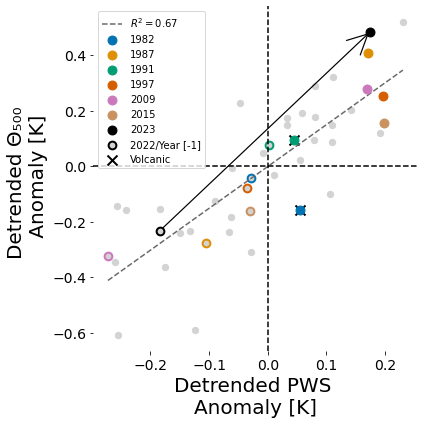

In [38]:
highlight_years = [1982, 1987, 1991, 1997, 2009, 2015]
volcanic_years = [1982, 1991]

fig, ax = plt.subplots(figsize=(6, 6))

residuals = plot_with_regression(
    ax,
    x=pws_aso.pws_detrended.values,
    y=t500_aso.det,
    x_label='Detrended PWS \nAnomaly [K]',
    years=pws_aso.year.values,
    highlight_years=highlight_years,
    volc_years=volcanic_years
)

plt.tight_layout()
plt.show()
fig.savefig('Figures/Fig4b.png', dpi = 600, format = 'png')



0.6710110274493958


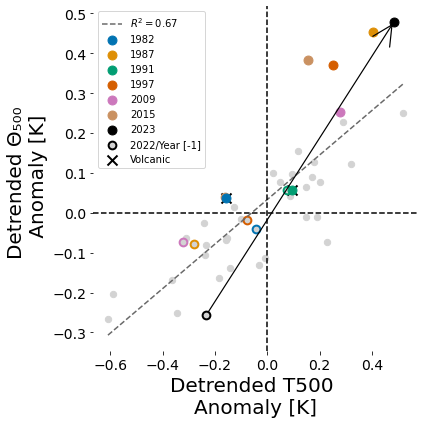

In [40]:
highlight_years = [1982, 1987, 1991, 1997, 2009, 2015]
volcanic_years = [1982, 1991]

fig, ax = plt.subplots(figsize=(6, 6))

residuals = plot_with_regression(
    ax,
    x=t500_aso.det,
    y=t2m_aso.t2m_detrended,
    x_label='Detrended T500 \nAnomaly [K]',
    years=pws_aso.year.values,
    highlight_years=highlight_years,
    volc_years=volcanic_years
)

plt.tight_layout()
plt.show()
#fig.savefig('Figures/Fig4b.png', dpi = 600, format = 'png')



# Residuals

In [41]:
#import sst full data for residual plotting
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst_full = decode_time(fp).sel(lat = slice(90,-90), time = slice('1979', '2023'))

sst_full_aso = sst_full.where(sst_full.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [42]:
from scipy.stats import pearsonr

# Assuming residuals and sst_full_aso.sst are already defined
def calc_corr_and_pval(residuals, sst, dim='year'):
    def corr_and_pval(x, y):
        mask = ~np.isnan(x) & ~np.isnan(y)  # Handle NaNs
        if mask.sum() < 2:  # Not enough data points
            return np.nan, np.nan
        r, p = pearsonr(x[mask], y[mask])
        return r, p
    
    return xr.apply_ufunc(
        corr_and_pval, 
        residuals, 
        sst,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

# Calculate correlation and p-values
corr, pval = calc_corr_and_pval(residuals, sst_full_aso.sst)

###  Ocean Mask

In [43]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-90,90))
ocean_mask = masks.seamask # mask for all contintnets

/tmp/ipykernel_785576/1477048082.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


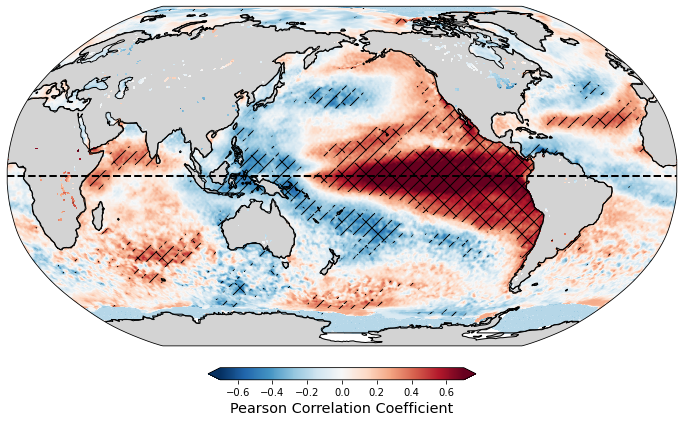

In [44]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(12, 8))

# Plot correlation using pcolormesh
cbar = ax.pcolormesh(corr.lon, corr.lat, corr, cmap='RdBu_r', transform=ccrs.PlateCarree(), shading='auto', vmin=-.7, vmax=.7)

# Add colorbar
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.4, pad=0.05, extend='both')
cb.set_label('Pearson Correlation Coefficient')

# Add hatching for p < 0.05
sig_mask_005 = pval < 0.05
ax.contourf(corr.lon, corr.lat, sig_mask_005, levels=[0.5, 1.5],
            hatches=['//'], colors='none', transform=ccrs.PlateCarree())

# Add hatching for p < 0.01
sig_mask_001 = pval < 0.01
ax.contourf(corr.lon, corr.lat, sig_mask_001, levels=[0.5, 1.5],
            hatches=['\\'], colors='none', transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Add ocean contour
ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
           levels=[0.5], colors='black', linewidths=1, transform=ccrs.PlateCarree())

# Add equator line
ax.axhline(0, linewidth=2, c='k', linestyle='--')

# Remove gridlines and axis decorations
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('')

plt.tight_layout()
plt.show()
fig.savefig('Figures/Fig4c.png', dpi = 600, format = 'png')



## SST Trend

In [42]:
# Define the function to compute linear trend (slope only)
def compute_slope(y, x=years):
    mask = np.isfinite(y)
    if mask.sum() < 2:  # not enough data points
        return np.nan
    return np.polyfit(x[mask], y[mask], 1)[0]  # return slope
def pattern_correlation(da1, da2):
    # Flatten and mask NaNs (shared mask)
    valid = np.isfinite(da1) & np.isfinite(da2)
    return np.corrcoef(da1.values[valid], da2.values[valid])[0, 1]
def weighted_pattern_correlation(da1, da2, weights):
    valid = np.isfinite(da1) & np.isfinite(da2)
    w = weights.broadcast_like(da1)
    w = w.where(valid)

    x = da1.where(valid)
    y = da2.where(valid)

    # Weighted covariance and variance
    x_mean = (x * w).sum() / w.sum()
    y_mean = (y * w).sum() / w.sum()
    
    cov = ((x - x_mean) * (y - y_mean) * w).sum() / w.sum()
    std_x = np.sqrt(((x - x_mean)**2 * w).sum() / w.sum())
    std_y = np.sqrt(((y - y_mean)**2 * w).sum() / w.sum())
    
    return (cov / (std_x * std_y)).item()

# Define a function that returns slope, r², p-value
def linregress_stats(y, x=years):
    mask = np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    res = linregress(x[mask], y[mask])
    return res.slope, res.rvalue**2, res.pvalue

In [43]:
## same but with restricted (45-45)
def pattern_correlation(da1, da2):
    # Restrict to latitude between -45 and 45
    da1 = da1.sel(lat=slice(45, -45))
    da2 = da2.sel(lat=slice(45, -45))
    
    # Flatten and mask NaNs (shared mask)
    valid = np.isfinite(da1) & np.isfinite(da2)
    return np.corrcoef(da1.values[valid], da2.values[valid])[0, 1]
def weighted_pattern_correlation(da1, da2, weights):
    # Restrict to latitude between -45 and 45
    da1 = da1.sel(lat=slice(45, -45))
    da2 = da2.sel(lat=slice(45, -45))
    weights = weights.sel(lat=slice(45, -45))
    
    valid = np.isfinite(da1) & np.isfinite(da2)
    w = weights.broadcast_like(da1)
    w = w.where(valid)

    x = da1.where(valid)
    y = da2.where(valid)

    # Weighted means
    x_mean = (x * w).sum() / w.sum()
    y_mean = (y * w).sum() / w.sum()

    # Weighted covariance and standard deviations
    cov = ((x - x_mean) * (y - y_mean) * w).sum() / w.sum()
    std_x = np.sqrt(((x - x_mean)**2 * w).sum() / w.sum())
    std_y = np.sqrt(((y - y_mean)**2 * w).sum() / w.sum())

    return (cov / (std_x * std_y)).item()


In [41]:


#import sst full data for residual plotting
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst_full = decode_time(fp).sel(lat = slice(90,-90), time = slice('1979', '2023'))

sst_full_aso = sst_full.where(sst_full.time.dt.month.isin([4,5,6,7,8,9])).groupby('time.year').mean()


ds = sst_full_aso.sel(year = slice(1979, 2020))
years = ds.year.values

In [44]:
# Apply across the "year" dimension
results = xr.apply_ufunc(
    linregress_stats,
    ds.sst,
    input_core_dims=[["year"]],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",  # Optional, depending on data size
    output_dtypes=[float, float, float]
)

# Unpack results
slope_map, r2_map, pval_map = results

# Label and organize
slope_map = slope_map.rename("slope")
r2_map = r2_map.rename("r_squared")
pval_map = pval_map.rename("p_value")

In [45]:
slope_da = slope_map.copy()
slope_da = slope_da - slope_da.mean(dim = 'lon')
slope_da = slope_da*10


In [46]:
# Apply along 'year' dimension
trend = xr.apply_ufunc(
    compute_slope,
    ds.sst,
    input_core_dims=[["year"]],
    vectorize=True,
    dask="parallelized",  # optional, useful for large datasets
    output_dtypes=[float]
)

In [47]:
# Save as a new dataset if you want

trend_da = trend.rename("sst_trend")
#sutract mean: 
trend_da = trend_da -trend_da.mean(dim = 'lon')
#convert to K/decade
trend_da = trend_da*10

In [48]:
weights = np.cos(np.deg2rad(trend_da.lat))
weighted_pattern_correlation(trend_da, corr, weights = weights)

0.1708924945154124

In [49]:
pattern_correlation(trend_da, corr)

0.1690419304979345

/tmp/ipykernel_821758/1791899112.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


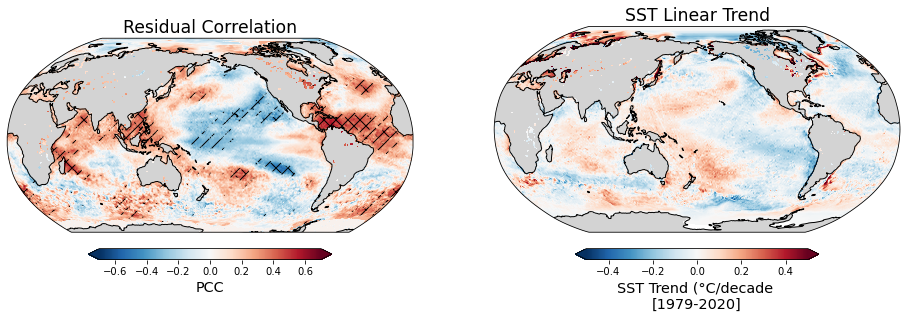

In [50]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': projection})

# --- First Plot: Pattern Correlation ---
ax = axes[0]
cbar = ax.pcolormesh(corr.lon, corr.lat, corr, cmap='RdBu_r', transform=ccrs.PlateCarree(), shading='auto', vmin=-0.7, vmax=0.7)
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, extend='both')
cb.set_label('PCC')

# Hatching for p-values
sig_mask_005 = pval < 0.05
sig_mask_001 = pval < 0.01
ax.contourf(corr.lon, corr.lat, sig_mask_005, levels=[0.5, 1.5], hatches=['//'], colors='none', transform=ccrs.PlateCarree())
ax.contourf(corr.lon, corr.lat, sig_mask_001, levels=[0.5, 1.5], hatches=['\\\\'], colors='none', transform=ccrs.PlateCarree())

# Features
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title('Residual Correlation')
ax.set_xticks([])
ax.set_yticks([])

# --- Second Plot: Trend ---
ax = axes[1]
tbar = ax.pcolormesh(trend_da.lon, trend_da.lat, trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), shading='auto', vmin = -0.5, vmax = 0.5)
tb = plt.colorbar(tbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, extend='both')
tb.set_label('SST Trend (°C/decade \n[1979-2020]')



ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title('SST Linear Trend')
ax.set_xticks([])
ax.set_yticks([])

# Layout and display
plt.tight_layout()
plt.show()


## Add correlation with PDF


In [51]:
pdv = -xr.open_dataset('/data/jmex/reg_sst_IPV_ERSSTv5_ERSST5_1900_2014_ANN.nc')

In [52]:
# interpolate trend_da and corr onto ipcc pattern
# Extract the target grid from the reference DataArray
target_lat = pdv.rc['lat']
target_lon = pdv.rc['lon']

# Interpolate 'corr' and 'trend_da' onto the target grid
corr_interp = corr.interp(lat=target_lat, lon=target_lon, method="linear")
pval_interp = pval.interp(lat=target_lat, lon=target_lon, method="linear")

slope_da_interp = slope_da.interp(lat=target_lat, lon=target_lon, method="linear")
pval_map_interp = pval_map.interp(lat=target_lat, lon=target_lon, method="linear")

In [53]:
weights = np.cos(np.deg2rad(pdv.rc.lat))
weighted_pattern_correlation(pdv.rc, corr_interp, weights = weights)

0.4209318815963896

In [54]:
weights = np.cos(np.deg2rad(slope_da_interp.lat))
weighted_pattern_correlation(slope_da_interp, corr_interp, weights = weights)

0.16968581175765576

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1508: UserWarning: The following kwargs were not used by contour: 'linewidth'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)
/tmp/ipykernel_821758/4272411877.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


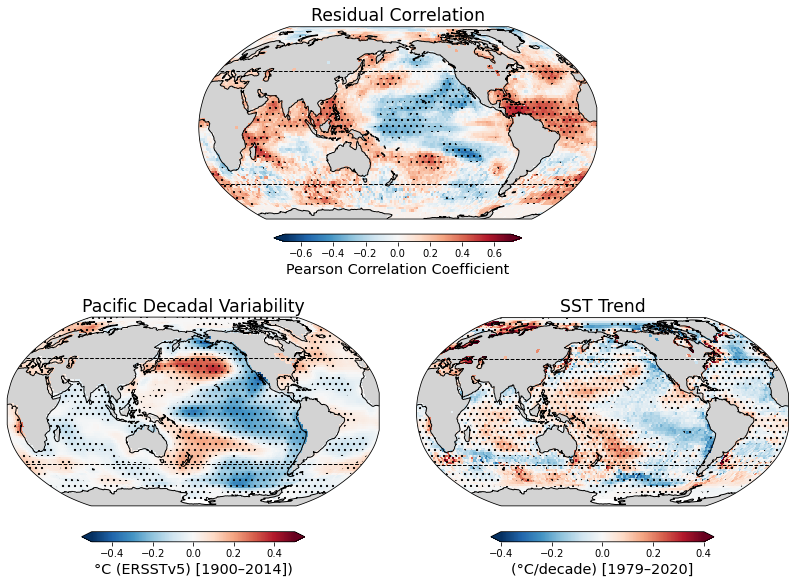

In [63]:
import matplotlib.gridspec as gridspec

# Projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.3, wspace=0.1)

# Define projections
proj = {'projection': projection}

# Top center plot (Residual Correlation) — span both columns
ax0 = fig.add_subplot(gs[0, :], **proj)

# Bottom left (PDV)
ax1 = fig.add_subplot(gs[1, 0], **proj)

# Bottom right (Trend)
ax2 = fig.add_subplot(gs[1, 1], **proj)


# Compute pattern correlations
pcc_trend_corr = pattern_correlation(slope_da_interp, corr_interp)
pcc_pdv_corr = pattern_correlation(pdv.rc, corr_interp)

# Projection
projection = ccrs.Robinson(central_longitude=180)


# --- 1. Residual Correlation ---
ax = ax0
cbar = ax.pcolormesh(corr_interp.lon, corr_interp.lat, corr_interp, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.7, vmax=0.7)
cb = fig.colorbar(cbar, ax=ax0, orientation='horizontal', fraction=0.035, pad=0.07, aspect=30, extend='both')
cb.set_label('Pearson Correlation Coefficient')

# Significance masking
sig_mask = pval_interp < 0.1
ax.contourf(corr_interp.lon, corr_interp.lat, sig_mask, levels=[0.5, 1.5],
            hatches=['..'], colors='none', transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title('Residual Correlation')
ax.set_xticks([])
ax.set_yticks([])

# --- 2. Trend Pattern ---
ax = ax2
tbar = ax.pcolormesh(slope_da_interp.lon, slope_da_interp.lat, slope_da_interp, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.4, vmax=0.4)
tb = plt.colorbar(tbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.1, extend='both')
tb.set_label('(°C/decade) [1979–2020]')

# Significance masking
sig_mask = pval_map_interp < 0.1
ax.contourf(slope_da_interp.lon, slope_da_interp.lat, sig_mask, levels=[0.5, 1.5],
            hatches=['..'], colors='none', transform=ccrs.PlateCarree())


# Draw ±45° latitude lines
ax.plot([0, 360], [45, 45], transform=ccrs.PlateCarree(), color='black', linestyle='--', linewidth=1)
ax.plot([0, 360], [-45, -45], transform=ccrs.PlateCarree(), color='black', linestyle='--', linewidth=1)


ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title(f'SST Trend')
ax.set_xticks([])
ax.set_yticks([])

# --- 3. PDV Pattern ---
ax = ax1
pbar = ax.pcolormesh(pdv.rc.lon, pdv.rc.lat, pdv.rc, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.5, vmax=0.5)
pb = plt.colorbar(pbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.1, extend='both')
pb.set_label('°C (ERSSTv5) [1900–2014])')

# Significance masking
sig_mask = -pdv.prob_rtest<0.1
ax.contourf(pdv.lon, pdv.lat, sig_mask, levels=[0.5, 1.5],
            hatches=['..'], colors='none', linewidth = 0.3, transform=ccrs.PlateCarree())


ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title(f'Pacific Decadal Variability')
ax.set_xticks([])
ax.set_yticks([])

# Final layout
for ax in [ax0, ax1, ax2]: 
    # Get full longitude range from the data
    lon_min = ax.get_extent(crs=ccrs.PlateCarree())[0]
    lon_max = ax.get_extent(crs=ccrs.PlateCarree())[1]
    lons = np.linspace(lon_min, lon_max, 100)

    # Add ±45° horizontal lines
    ax.plot(lons, np.full_like(lons, 45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)
    ax.plot(lons, np.full_like(lons, -45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)


plt.tight_layout()
plt.show()
fig.savefig('Figures/FigS8.png', dpi = 600, format = 'png')




In [56]:
# Compute pattern correlations
pcc_trend_corr = pattern_correlation(trend_da_interp, corr_interp)
pcc_pdv_corr = pattern_correlation(pdv.rc, corr_interp)
pcc_pdv_trend = pattern_correlation(pdv.rc, trend_da_interp)


NameError: name 'trend_da_interp' is not defined

In [ ]:
print(pcc_trend_corr, pcc_pdv_corr, pcc_pdv_trend)

In [ ]:
from scipy.stats import pearsonr

def pattern_correlation(da1, da2):
    # Restrict to latitude between -45 and 45
    da1 = da1.sel(lat=slice(45, -45))
    da2 = da2.sel(lat=slice(45, -45))
    
    # Flatten and mask NaNs (shared mask)
    valid = np.isfinite(da1) & np.isfinite(da2)
    corr, p_value = pearsonr(da1.values[valid], da2.values[valid])
    print(f"Correlation: {corr:.4f}, p-value: {p_value:.4e}")
    return corr


In [ ]:
# Compute pattern correlations
pcc_trend_corr = pattern_correlation(trend_da_interp, corr_interp)
pcc_pdv_corr = pattern_correlation(pdv.rc, corr_interp)
pcc_pdv_trend = pattern_correlation(pdv.rc, trend_da_interp)
print(pcc_trend_corr, pcc_pdv_corr, pcc_pdv_trend)

In [ ]:
plt.scatter(pdv.rc.values.flatten(), trend_da_interp.values.flatten()) 

## Part for Rad

In [57]:
#import sst full data for residual plotting
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(90,-90), time = slice('1979', '2023'))


In [58]:
#AMJJAS means
sst_amjjas = sst.where(sst.time.dt.month.isin([4,5,6,7,8,9]), drop = True).groupby('time.year').mean()

In [59]:
## make composite
composite_years = [1982, 1987, 1991, 1997, 2015, 2009]

sst_composite = sst_amjjas.where(sst_amjjas.year.isin(composite_years)).mean('year')

#sst 2023
sst_2023 = sst_amjjas.sel(year = 2023)


#ake diff
sst_diff = sst_2023 - sst_composite

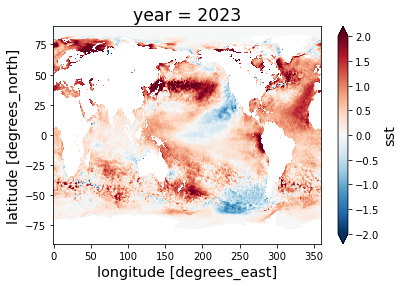

In [60]:
sst_diff.sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2)

In [61]:
# interpolate trend_da and corr onto ipcc pattern
# Extract the target grid from the reference DataArray
target_lat = pdv.rc['lat']
target_lon = pdv.rc['lon']

# Interpolate 'corr' and 'trend_da' onto the target grid
sst_diff_interp = sst_diff.interp(lat=target_lat, lon=target_lon, method="linear")

In [62]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Compute pattern correlations
pcc_trend_corr = pattern_correlation(trend_da_interp, sst_diff_interp.sst)
pcc_pdv_corr = pattern_correlation(pdv.rc, sst_diff_interp.sst)

# Projection
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axes
fig, axes = plt.subplots(1, 3, figsize=(22, 6), subplot_kw={'projection': projection})

# --- 1. Residual Correlation ---
ax = axes[0]
cbar = ax.pcolormesh(sst_diff_interp.lon, sst_diff_interp.lat, sst_diff_interp.sst, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-3, vmax=3)
cb = plt.colorbar(cbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, extend='both')
cb.set_label(r'$\Delta SST$')


ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title('2023 - Composite')
ax.set_xticks([])
ax.set_yticks([])

# --- 2. Trend Pattern ---
ax = axes[1]
tbar = ax.pcolormesh(trend_da_interp.lon, trend_da_interp.lat, trend_da_interp, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.5, vmax=0.5)
tb = plt.colorbar(tbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, extend='both')
tb.set_label('SST Trend (°C/decade) [1979–2020]')

# Draw ±45° latitude lines
ax.plot([0, 360], [45, 45], transform=ccrs.PlateCarree(), color='black', linestyle='--', linewidth=1)
ax.plot([0, 360], [-45, -45], transform=ccrs.PlateCarree(), color='black', linestyle='--', linewidth=1)


ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title(f'SST Trend\nPCC = {pcc_trend_corr:.2f}')
ax.set_xticks([])
ax.set_yticks([])

# --- 3. PDV Pattern ---
ax = axes[2]
pbar = ax.pcolormesh(pdv.rc.lon, pdv.rc.lat, pdv.rc, cmap='RdBu_r',
                     transform=ccrs.PlateCarree(), shading='auto', vmin=-0.5, vmax=0.5)
pb = plt.colorbar(pbar, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, extend='both')
pb.set_label('PDV Pattern')

    
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')
ax.set_title(f'PDV Spatial Pattern\nPCC = {pcc_pdv_corr:.2f}')
ax.set_xticks([])
ax.set_yticks([])

# Final layout
for ax in axes: 
    # Get full longitude range from the data
    lon_min = ax.get_extent(crs=ccrs.PlateCarree())[0]
    lon_max = ax.get_extent(crs=ccrs.PlateCarree())[1]
    lons = np.linspace(lon_min, lon_max, 100)

    # Add ±45° horizontal lines
    ax.plot(lons, np.full_like(lons, 45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)
    ax.plot(lons, np.full_like(lons, -45), transform=ccrs.PlateCarree(),
            color='black', linestyle='--', linewidth=1, zorder=5)


plt.tight_layout()
plt.show()



NameError: name 'trend_da_interp' is not defined

In [ ]:
pattern_correlation(corr_interp, sst_diff_interp.sst)

## T500 Jump

In [43]:
dp = pws_aso - pws_aso.roll(year = 1)
dp = dp.drop_isel(year = 1)

In [44]:
dp.pws_mean

<xarray.DataArray 'pws_mean' (year: 44)>
array([-0.8487549 , -0.13626099,  0.04522705,  0.08956909, -0.20535278,
       -0.10131836,  0.11846924,  0.33251953, -0.14849854, -0.24746704,
        0.24081421,  0.03961182, -0.08752441, -0.01419067,  0.02212524,
        0.24624634, -0.14334106,  0.2444458 ,  0.07720947, -0.47140503,
        0.08062744,  0.27938843, -0.0178833 ,  0.04388428, -0.10760498,
        0.1251831 , -0.07611084,  0.01144409, -0.21697998,  0.39364624,
       -0.11877441, -0.21936035,  0.10040283,  0.08847046,  0.01507568,
        0.26382446, -0.00875854, -0.05908203, -0.26739502,  0.25888062,
        0.09173584, -0.21664429, -0.02038574,  0.4281006 ], dtype=float32)
Coordinates:
  * year     (year) int64 1979 1981 1982 1983 1984 ... 2019 2020 2021 2022 2023

In [70]:
dt = t500_aso - t500_aso.roll(year  = 1)
dt = dt.drop_isel(year = 1)

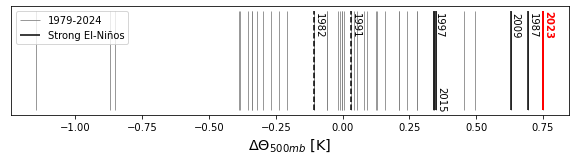

In [ ]:
# Assuming dt.ocean_mean and dt.year exist


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt_composite = dt.where(dt.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt.ocean_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt.sel(year = 1982).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1987).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 1991).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1997).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2009).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2015).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt_composite.year.values: 

    if y == 2015: 
        x = dt.sel(year = y).ocean_mean
        ax.annotate(y, (x, 0.), rotation = 270)
        continue
    x = dt.sel(year = y).ocean_mean
    ax.annotate(y, (x, 0.75), rotation = 270)        

x = dt.sel(year= 2023).ocean_mean
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel(r"ΔΘ$_{500mb}$ [K]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dt.ocean_mean")

plt.legend(loc = 'upper left')
fig.savefig('Figures/FigS7a.png', dpi = 600, format = 'png', bbox_inches='tight')
plt.show()




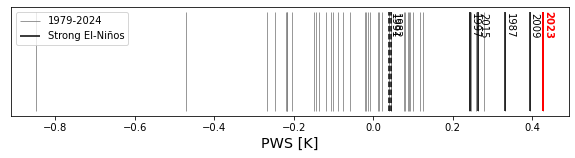

In [48]:
# Assuming dp.pws_mean and dp.year exist


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dp_composite = dp.where(dp.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dp.pws_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dp.sel(year = 1982).pws_mean, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dp.sel(year = 1987).pws_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dp.sel(year = 1991).pws_mean, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dp.sel(year = 1997).pws_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dp.sel(year = 2009).pws_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dp.sel(year = 2015).pws_mean, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dp_composite.year.values: 
    x = dp.sel(year = y).pws_mean
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dp.sel(year= 2023).pws_mean
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel(f"PWS [K]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dp.pws_mean")

plt.legend(loc = 'upper left')
plt.show()


In [ ]:
dp